In [1]:
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
import warnings
from matplotlib import gridspec
from scipy.stats import levene

In [2]:
file = '../data/mice_data.xlsx'
sheets = ['FemTemp', 'FemAct', 'MaleTemp', 'MaleAct']

data = {s:pd.read_excel(file, sheet_name = s, index_col = 0) for s in sheets}
for key, df in data.items():
    df.index = df.index / (60 * 24)

In [3]:
def preprocess(df):
    df = df.apply(detrend, axis=0)
    df = (df - df.mean()) / df.std()
    return df
processed_data = data
for key in data:
    processed_data[key] = preprocess(data[key])

Top minutes (0–1439): [9.5, 8.666666666666666, 11.0, 10.916666666666666, 8.916666666666666, 11.583333333333334, 9.583333333333334, 9.416666666666666, 8.7, 8.5]
Scores: [5 5 4 4 4 4 4 3 3 3]


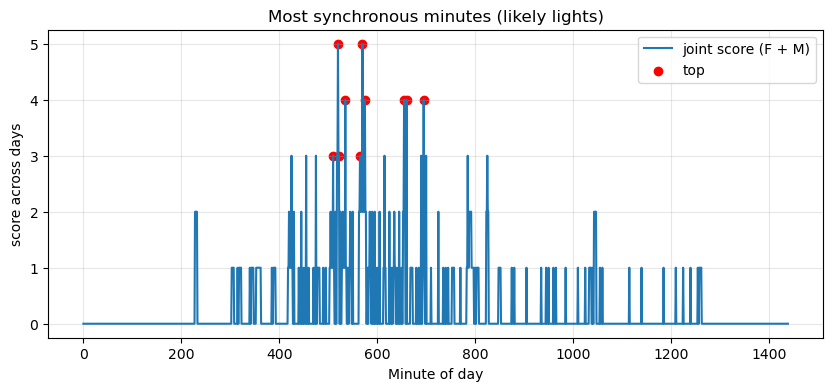

In [4]:
DAY = 1440
n_days = len(processed_data['FemTemp']) // DAY
penalty = 50

fem_cols = processed_data["FemTemp"].columns[1:]
male_cols = processed_data["MaleTemp"].columns[1:]

fem_day_counts = np.zeros(DAY, int)
male_day_counts = np.zeros(DAY, int)

for d in range(n_days):
    start, end = d*DAY, (d+1)*DAY
    fem_day = processed_data["FemTemp"].iloc[start:end, :]
    male_day = processed_data["MaleTemp"].iloc[start:end, :]

    fem_cp = np.zeros(DAY, int)
    male_cp = np.zeros(DAY, int)

    for col in fem_cols:
        x = fem_day[col].astype(float).values
        cps = rpt.Pelt(model="l2").fit(x).predict(pen = 200)
        for cp in cps[:-1]:
            if cp < DAY:
                fem_cp[cp] += 1

    for col in male_cols:
        x = male_day[col].astype(float).values
        cps = rpt.Pelt(model="l2").fit(x).predict(pen = 200)
        for cp in cps[:-1]:
            if cp < DAY:
                male_cp[cp] += 1

    male_win = np.zeros(DAY, int)
    for t in range(DAY):
        lo = max(0, t-2); hi = min(DAY, t+3)
        male_win[t] = male_cp[lo:hi].max()

    fem_day_counts += fem_cp
    male_day_counts += male_win

joint_score = fem_day_counts + male_day_counts

top_idx = np.argsort(joint_score)[::-1][:10]
print("Top minutes (0–1439):", [cp / 60 for cp in top_idx])
print("Scores:", joint_score[top_idx])

t = np.arange(DAY)
plt.figure(figsize=(10,4))
plt.plot(t, joint_score, label="joint score (F + M)", linewidth=1.5)
plt.scatter(top_idx, joint_score[top_idx], color="red", label="top")
plt.xlabel("Minute of day")
plt.ylabel("score across days")
plt.title("Most synchronous minutes (likely lights)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Top minutes (0–1439): [12.0, 11.983333333333333, 12.033333333333333, 12.016666666666667, 11.966666666666667, 0.06666666666666667, 8.283333333333333, 7.95, 7.966666666666667, 7.983333333333333]
Scores: [139  38  38  38  38   0   0   0   0   0]


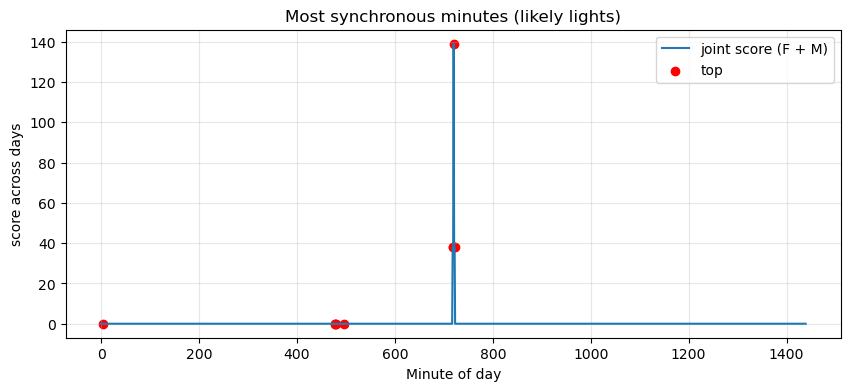

In [5]:
DAY = 1440
n_days = len(processed_data['FemTemp']) // DAY
penalty = 50

fem_cols = processed_data["FemTemp"].columns[1:]
male_cols = processed_data["MaleTemp"].columns[1:]

fem_day_counts = np.zeros(DAY, int)
male_day_counts = np.zeros(DAY, int)

for d in range(n_days):
    start, end = d*DAY, (d+1)*DAY
    fem_day = processed_data["FemTemp"].iloc[start:end, :]
    male_day = processed_data["MaleTemp"].iloc[start:end, :]

    fem_cp = np.zeros(DAY, int)
    male_cp = np.zeros(DAY, int)

    for col in fem_cols:
        x = fem_day[col].astype(float).values
        cps = rpt.Pelt(model="l2", min_size=720).fit(x).predict(pen = 200)
        for cp in cps[:-1]:
            if cp < DAY:
                fem_cp[cp] += 1

    for col in male_cols:
        x = male_day[col].astype(float).values
        cps = rpt.Pelt(model="l2", min_size=720).fit(x).predict(pen = 200)
        for cp in cps[:-1]:
            if cp < DAY:
                male_cp[cp] += 1

    male_win = np.zeros(DAY, int)
    for t in range(DAY):
        lo = max(0, t-2); hi = min(DAY, t+3)
        male_win[t] = male_cp[lo:hi].max()

    fem_day_counts += fem_cp
    male_day_counts += male_win

joint_score = fem_day_counts + male_day_counts

top_idx = np.argsort(joint_score)[::-1][:10]
print("Top minutes (0–1439):", [cp / 60 for cp in top_idx])
print("Scores:", joint_score[top_idx])

t = np.arange(DAY)
plt.figure(figsize=(10,4))
plt.plot(t, joint_score, label="joint score (F + M)", linewidth=1.5)
plt.scatter(top_idx, joint_score[top_idx], color="red", label="top")
plt.xlabel("Minute of day")
plt.ylabel("score across days")
plt.title("Most synchronous minutes (likely lights)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Plotting for penalty = 200


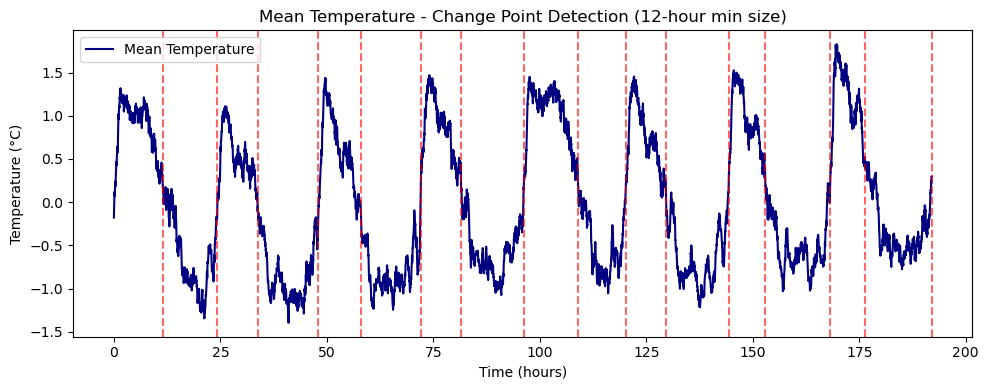

In [6]:
# Compute mean across mice
temp_mean = processed_data["FemTemp"].mean(axis=1)

# Convert time to hours (assuming 1 sample per minute)
time_hours = np.arange(len(temp_mean)) / 60  

# Define minimum segment size for 12-hour separation
min_size = 12 * 60  # 12 hours * 60 minutes/hour = 720 samples

# Fit change point detection model
algo = rpt.Pelt(model="l2").fit(temp_mean.to_numpy().reshape(-1, 1))
result = algo.predict(pen=200)

print(f"Plotting for penalty = 200")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time_hours, temp_mean, label="Mean Temperature", color="navy")
for cp in result:
    plt.axvline(time_hours[cp - 1], color="red", linestyle="--", alpha=0.6)
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (°C)")
plt.title("Mean Temperature - Change Point Detection (12-hour min size)")
plt.tight_layout()
plt.legend()
plt.show()

In [8]:
algo = rpt.Pelt(model="l2", min_size=720).fit(temp_mean.to_numpy().reshape(-1, 1))
result = algo.predict(pen=200)
result_hours12 = [cp / 60 for cp in result]
result_hours12
algo = rpt.Pelt(model="l2", min_size= 360).fit(temp_mean.to_numpy().reshape(-1, 1))
result_samples = algo.predict(pen= 200)
result_hours6 = [cp / 60 for cp in result_samples]
result_hours6
algo = rpt.Pelt(model="l2").fit(temp_mean.to_numpy().reshape(-1, 1))
result_samples = algo.predict(pen= 200)
result_hours = [cp / 60 for cp in result_samples]
result_hours

[11.583333333333334,
 24.333333333333332,
 33.833333333333336,
 48.0,
 58.0,
 72.0,
 81.58333333333333,
 96.25,
 108.91666666666667,
 120.16666666666667,
 129.66666666666666,
 144.33333333333334,
 152.91666666666666,
 168.25,
 176.33333333333334,
 192.0]

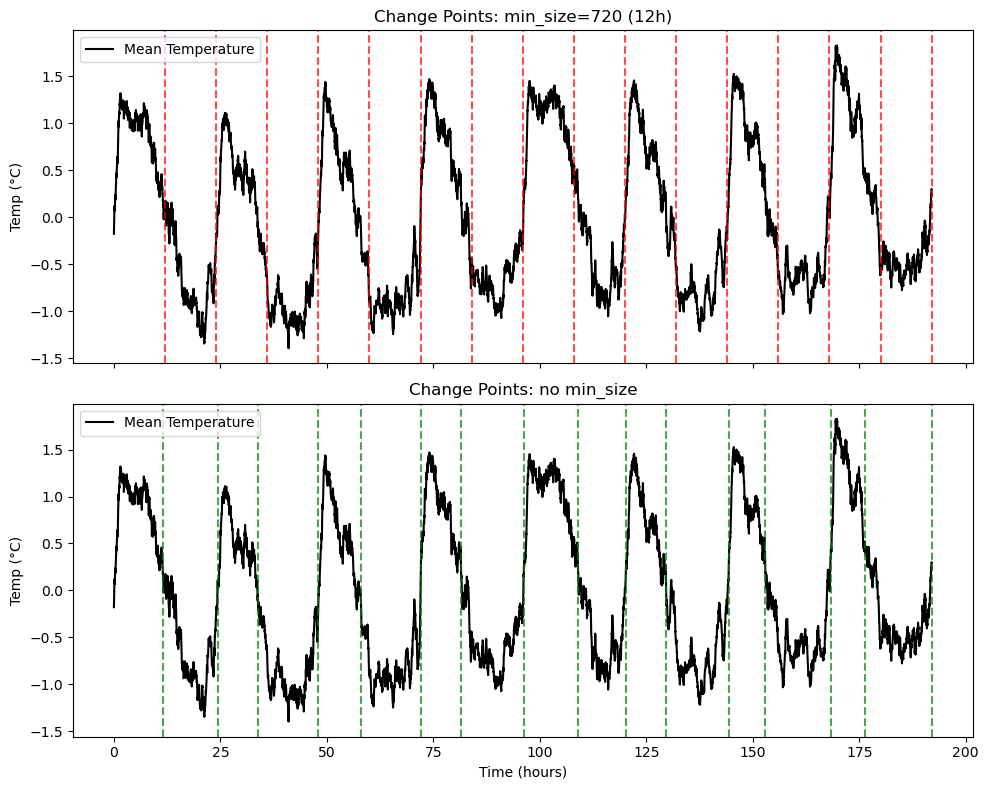

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

configs = [
    ("min_size=720 (12h)", result_hours12, "red"),
    ("no min_size", result_hours, "green")
]

for ax, (label, cps, color) in zip(axes, configs):
    ax.plot(time_hours, temp_mean, color="black", label="Mean Temperature")
    for cp in cps:
        ax.axvline(cp, color=color, linestyle="--", alpha=0.7)
    ax.set_ylabel("Temp (°C)")
    ax.set_title(f"Change Points: {label}")
    ax.legend()

plt.xlabel("Time (hours)")
plt.tight_layout()
plt.show()
